# EDA Explration

In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "stroke_risk_dataset.csv"
df = pd.read_csv(data_path)
print("Shape:", df.shape)
display(df.head(3))

Shape: (70000, 18)


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1


In [3]:
display(df.dtypes)


df["Age"] = pd.to_numeric(df["Age"], errors="coerce")


df["Stroke Risk (%)"] = pd.to_numeric(df["Stroke Risk (%)"], errors="coerce")


Chest Pain                          int64
Shortness of Breath                 int64
Irregular Heartbeat                 int64
Fatigue & Weakness                  int64
Dizziness                           int64
Swelling (Edema)                    int64
Pain in Neck/Jaw/Shoulder/Back      int64
Excessive Sweating                  int64
Persistent Cough                    int64
Nausea/Vomiting                     int64
High Blood Pressure                 int64
Chest Discomfort (Activity)         int64
Cold Hands/Feet                     int64
Snoring/Sleep Apnea                 int64
Anxiety/Feeling of Doom             int64
Age                                 int64
Stroke Risk (%)                   float64
At Risk (Binary)                    int64
dtype: object

In [4]:
df.dtypes

Chest Pain                          int64
Shortness of Breath                 int64
Irregular Heartbeat                 int64
Fatigue & Weakness                  int64
Dizziness                           int64
Swelling (Edema)                    int64
Pain in Neck/Jaw/Shoulder/Back      int64
Excessive Sweating                  int64
Persistent Cough                    int64
Nausea/Vomiting                     int64
High Blood Pressure                 int64
Chest Discomfort (Activity)         int64
Cold Hands/Feet                     int64
Snoring/Sleep Apnea                 int64
Anxiety/Feeling of Doom             int64
Age                                 int64
Stroke Risk (%)                   float64
At Risk (Binary)                    int64
dtype: object

In [5]:
unique_summary = pd.DataFrame({
    "n_unique": df.nunique(dropna=False),
    "unique_values_sample": df.apply(lambda s: sorted(s.dropna().unique())[:10])
})
display(unique_summary.sort_values("n_unique"))


,n_unique,unique_values_sample
Chest Pain,2,"[0, 1]"
Shortness of Breath,2,"[0, 1]"
Irregular Heartbeat,2,"[0, 1]"
Fatigue & Weakness,2,"[0, 1]"
Dizziness,2,"[0, 1]"
Swelling (Edema),2,"[0, 1]"
Pain in Neck/Jaw/Shoulder/Back,2,"[0, 1]"
Excessive Sweating,2,"[0, 1]"
Persistent Cough,2,"[0, 1]"
Nausea/Vomiting,2,"[0, 1]"


In [6]:
df["At Risk (Binary)"].value_counts()
df["At Risk (Binary)"].value_counts(normalize=True) * 100

At Risk (Binary)
1    64.92
0    35.08
Name: proportion, dtype: float64

In [7]:
df["Stroke Risk (%)"].describe()

count    70000.000000
mean        55.558771
std         14.300898
min          5.000000
25%         45.500000
50%         55.500000
75%         66.000000
max        100.000000
Name: Stroke Risk (%), dtype: float64

In [8]:
df.groupby("At Risk (Binary)")["Stroke Risk (%)"].describe()

,count,mean,std,min,25%,50%,75%,max
At Risk (Binary),,,,,,,,
0,24556.0,40.175273,7.146984,5.0,36.0,41.5,46.0,49.5
1,45444.0,63.871358,9.510467,50.0,56.0,62.5,70.0,100.0


In [9]:
df.groupby("At Risk (Binary)")["Stroke Risk (%)"].mean()

At Risk (Binary)
0    40.175273
1    63.871358
Name: Stroke Risk (%), dtype: float64

In [10]:
df["Age"].describe()


count    70000.000000
mean        54.056429
std         21.071567
min         18.000000
25%         36.000000
50%         54.000000
75%         72.000000
max         90.000000
Name: Age, dtype: float64

In [11]:
df[df["Stroke Risk (%)"] > 100]
df[df["Stroke Risk (%)"] < 0]

df[df["Age"] > 120]
df[df["Age"] < 0]

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)


In [12]:
missing_count = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(3)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

display(missing_summary)

,Missing Count,Missing %
Chest Pain,0,0.0
Shortness of Breath,0,0.0
Irregular Heartbeat,0,0.0
Fatigue & Weakness,0,0.0
Dizziness,0,0.0
Swelling (Edema),0,0.0
Pain in Neck/Jaw/Shoulder/Back,0,0.0
Excessive Sweating,0,0.0
Persistent Cough,0,0.0
Nausea/Vomiting,0,0.0


In [13]:
missing_only = missing_summary[missing_summary['Missing Count'] > 0]
display(missing_only)

,Missing Count,Missing %


In [14]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_without_missing = (~df.isna().any(axis=1)).sum()

print("Rows with at least one missing value:", rows_with_missing)
print("Complete rows (no missing):", rows_without_missing)

Rows with at least one missing value: 0
Complete rows (no missing): 70000


In [15]:
feature_cols = [col for col in df.columns if col not in ['Stroke Risk (%)', 'At Risk (Binary)']]

feature_missing = df[feature_cols].isna().sum().sort_values(ascending=False)
feature_missing_pct = (df[feature_cols].isna().mean() * 100).sort_values(ascending=False)

feature_missing_summary = pd.DataFrame({
    'Missing Count': feature_missing,
    'Missing %': feature_missing_pct.round(3)
})

display(feature_missing_summary[feature_missing_summary['Missing Count'] > 0])

,Missing Count,Missing %


In [16]:
from sklearn.impute import SimpleImputer

binary_cols = [col for col in df.columns 
               if col not in ["Age", "Stroke Risk (%)", "At Risk (Binary)"]]

imputer = SimpleImputer(strategy="most_frequent")

df[binary_cols] = imputer.fit_transform(df[binary_cols])

In [17]:
df[binary_cols] = df[binary_cols].astype(int)

In [18]:
df.isna().sum()

Chest Pain                        0
Shortness of Breath               0
Irregular Heartbeat               0
Fatigue & Weakness                0
Dizziness                         0
Swelling (Edema)                  0
Pain in Neck/Jaw/Shoulder/Back    0
Excessive Sweating                0
Persistent Cough                  0
Nausea/Vomiting                   0
High Blood Pressure               0
Chest Discomfort (Activity)       0
Cold Hands/Feet                   0
Snoring/Sleep Apnea               0
Anxiety/Feeling of Doom           0
Age                               0
Stroke Risk (%)                   0
At Risk (Binary)                  0
dtype: int64

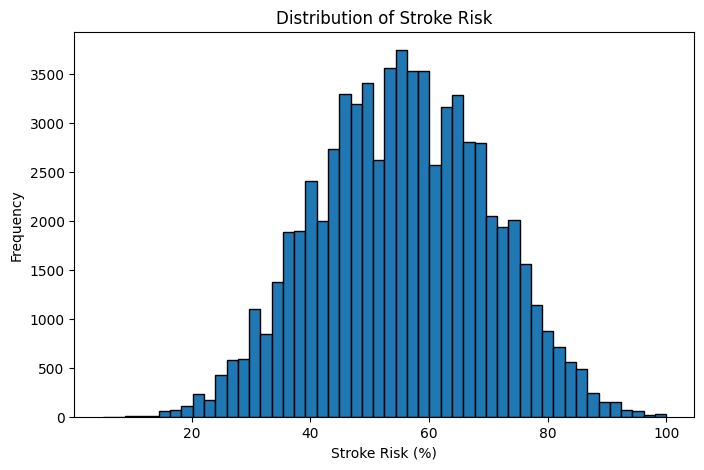

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Stroke Risk (%)"], bins=50, edgecolor="black")
plt.xlabel("Stroke Risk (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Stroke Risk")
plt.show()

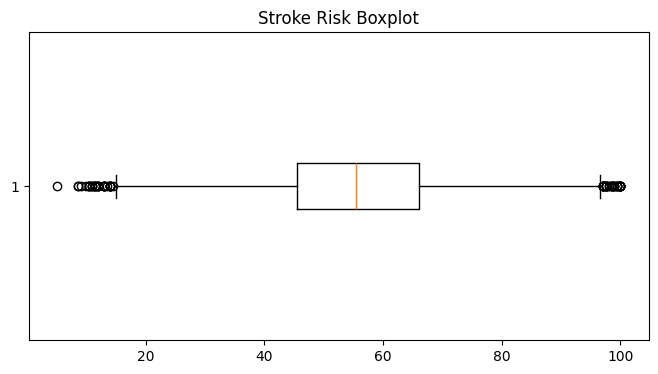

In [20]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Stroke Risk (%)"], vert=False)
plt.title("Stroke Risk Boxplot")
plt.show()

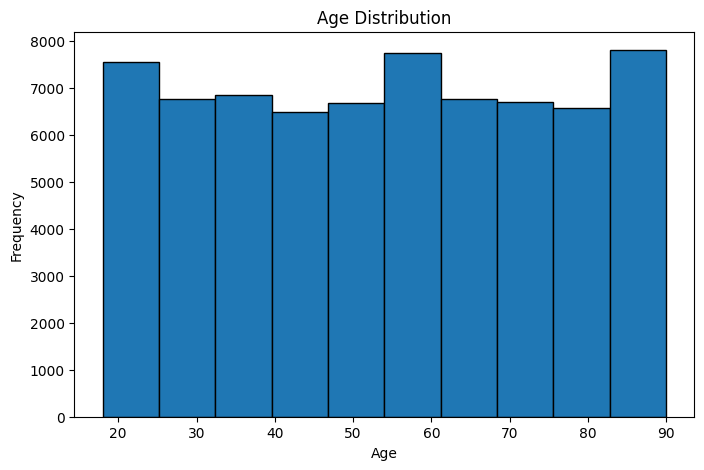

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

In [22]:
df["Age"].value_counts().sort_index()

Age
18     925
19     975
20     933
21     951
22     892
      ... 
86     952
87     951
88    1018
89     993
90     939
Name: count, Length: 73, dtype: int64

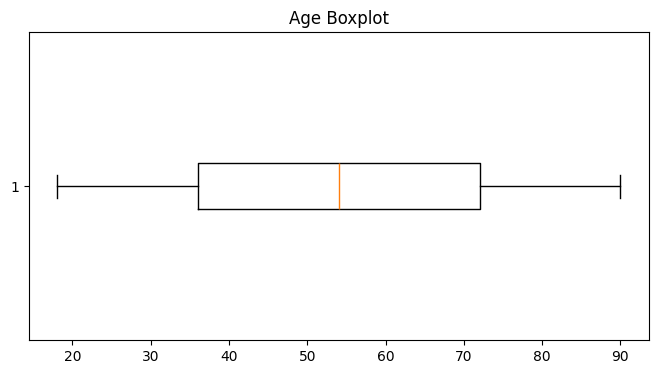

In [23]:
plt.figure(figsize=(8,4))
plt.boxplot(df["Age"], vert=False)
plt.title("Age Boxplot")
plt.show()

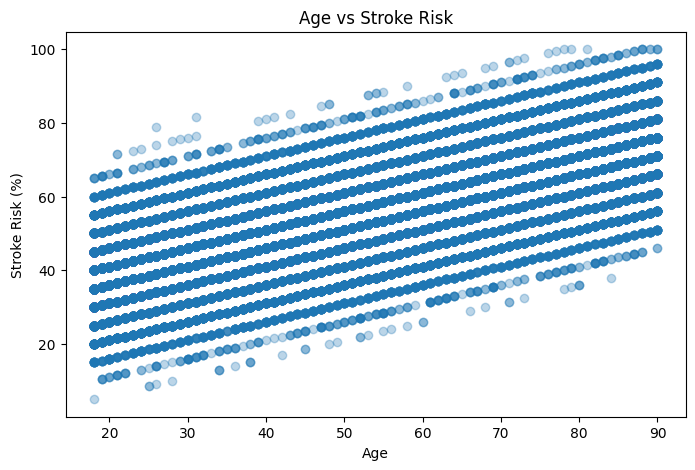

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Stroke Risk (%)"], alpha=0.3)

plt.xlabel("Age")
plt.ylabel("Stroke Risk (%)")
plt.title("Age vs Stroke Risk")

plt.show()

In [25]:
df[["Age", "Stroke Risk (%)"]].corr()

,Age,Stroke Risk (%)
Age,1.000000,0.733862
Stroke Risk (%),0.733862,1.000000


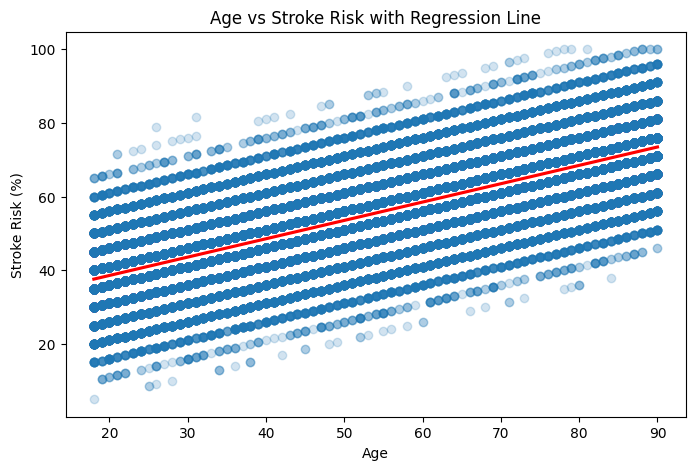

In [26]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    x="Age",
    y="Stroke Risk (%)",
    data=df,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Age vs Stroke Risk with Regression Line")
plt.show()

In [27]:
binary_cols = [col for col in df.columns 
               if col not in ["Age", "Stroke Risk (%)", "At Risk (Binary)"]]

impact = []

for col in binary_cols:
    
    risk_with = df[df[col]==1]["Stroke Risk (%)"].mean()
    risk_without = df[df[col]==0]["Stroke Risk (%)"].mean()
    
    impact.append({
        "Symptom": col,
        "Risk with symptom": risk_with,
        "Risk without symptom": risk_without,
        "Impact": risk_with - risk_without
    })

impact_df = pd.DataFrame(impact)

impact_df.sort_values("Impact", ascending=False)

,Symptom,Risk with symptom,Risk without symptom,Impact
0,Chest Pain,58.176966,52.920904,5.256062
12,Cold Hands/Feet,58.143882,52.985305,5.158577
13,Snoring/Sleep Apnea,58.129636,52.980845,5.148791
10,High Blood Pressure,58.120345,52.990602,5.129743
1,Shortness of Breath,58.124795,53.028712,5.096083
3,Fatigue & Weakness,58.090953,53.025577,5.065377
14,Anxiety/Feeling of Doom,58.081807,53.037033,5.044773
7,Excessive Sweating,58.047083,53.033647,5.013436
4,Dizziness,58.047369,53.039699,5.007670
9,Nausea/Vomiting,58.016436,53.081933,4.934503


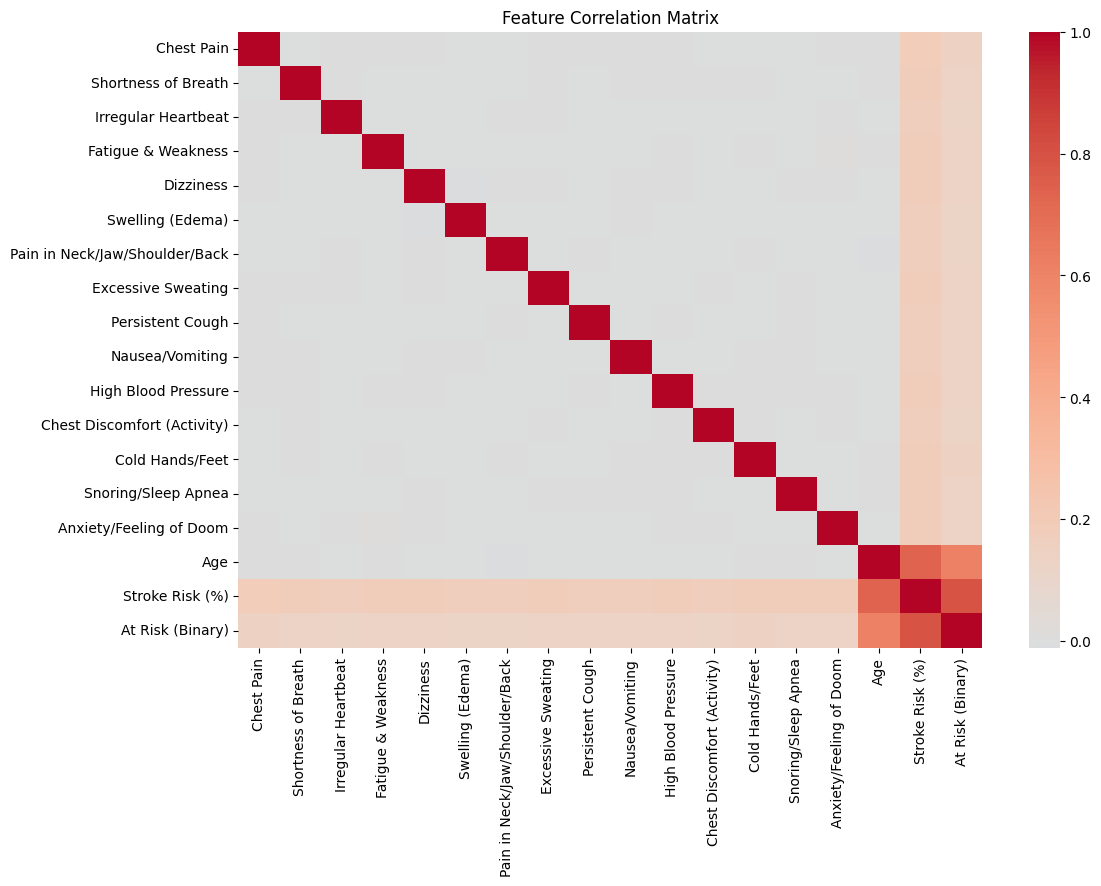

In [28]:
corr = df.corr()

plt.figure(figsize=(12,8))

import seaborn as sns

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

# Pre-Modeling Preparation

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Stroke Risk (%)", "At Risk (Binary)"])
y = df["Stroke Risk (%)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

rmse = np.sqrt(mse)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

# إنشاء الجدول
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"],
    "Value": [mae, mse, rmse, mape, r2, adj_r2]
})

print(results)

        Metric     Value
0          MAE  0.000950
1          MSE  0.000161
2         RMSE  0.012691
3         MAPE  0.000017
4           R2  0.999999
5  Adjusted R2  0.999999


# Feature Selection


## StrokeRisk=b0​+b1​X1​+b2​X2​+...

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model = LinearRegression()

model.fit(X_scaled, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["abs_coef"] = importance["Coefficient"].abs()

importance.sort_values("abs_coef", ascending=False)

,Feature,Coefficient,abs_coef
15,Age,10.535333,10.535333
2,Irregular Heartbeat,2.500092,2.500092
14,Anxiety/Feeling of Doom,2.499816,2.499816
11,Chest Discomfort (Activity),2.499813,2.499813
0,Chest Pain,2.499789,2.499789
6,Pain in Neck/Jaw/Shoulder/Back,2.499777,2.499777
10,High Blood Pressure,2.499775,2.499775
13,Snoring/Sleep Apnea,2.499775,2.499775
3,Fatigue & Weakness,2.499773,2.499773
12,Cold Hands/Feet,2.499768,2.499768


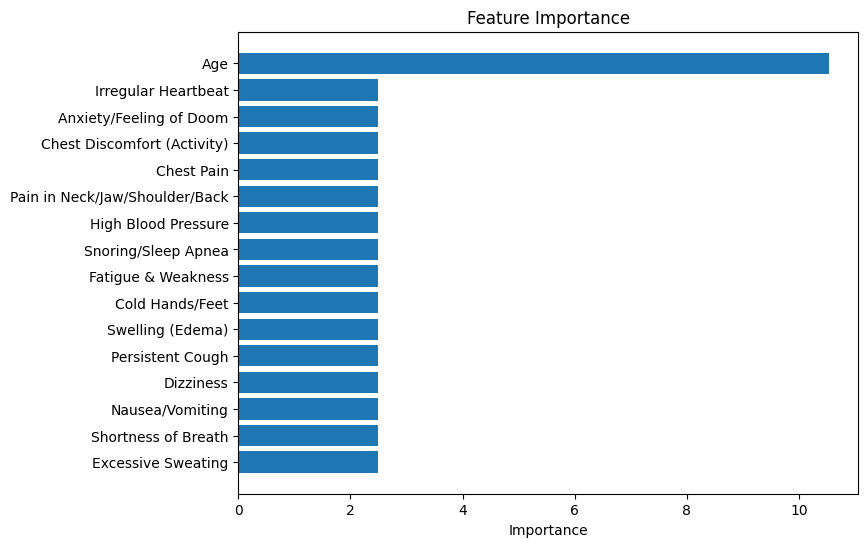

In [33]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values("abs_coef")

plt.figure(figsize=(8,6))

plt.barh(importance_sorted["Feature"], importance_sorted["abs_coef"])

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.show()

### Feature Importance Analysis

The feature importance results show that Age is the most influential factor affecting stroke risk prediction.
All medical symptoms have similar coefficients, indicating that each symptom contributes approximately equally to the predicted stroke risk.
This suggests that stroke risk increases significantly with age, while symptoms moderately increase the overall risk score

# Model Comparison

### Linear Models

Linear Regression

Ridge

Lasso

ElasticNet

### Tree-Based Models

Decision Tree Regressor

Random Forest Regressor

Extra Trees Regressor

Gradient Boosting Regressor

### Boosting

AdaBoost Regressor

### Kernel-based

SVR

### Neighbors

KNeighborsRegressor

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# =========================
# 1) Define X and y
# =========================
X = df.drop(columns=["Stroke Risk (%)", "At Risk (Binary)"])
y = df["Stroke Risk (%)"]

# =========================
# 2) Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 3) Define models
# =========================
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01))
    ]),
    
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
    
    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(random_state=42, n_estimators=200))
    ]),
    
    "Extra Trees": Pipeline([
        ("model", ExtraTreesRegressor(random_state=42, n_estimators=200))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    
    "AdaBoost": Pipeline([
        ("model", AdaBoostRegressor(random_state=42, n_estimators=100))
    ]),
    
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ])
}

# =========================
# 4) Train and evaluate
# =========================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Adjusted R2": adj_r2
    })

# =========================
# 5) Results table
# =========================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="R2", ascending=False)

results_df = results_df.round(4)

display(results_df)

            Model    MAE     MSE   RMSE   MAPE     R2  Adjusted R2
Linear Regression 0.0010  0.0002 0.0127 0.0000 1.0000       1.0000
            Ridge 0.0011  0.0002 0.0127 0.0000 1.0000       1.0000
            Lasso 0.0324  0.0018 0.0421 0.0007 1.0000       1.0000
       ElasticNet 0.0717  0.0080 0.0892 0.0015 1.0000       1.0000
              SVR 0.0757  0.0081 0.0897 0.0015 1.0000       1.0000
Gradient Boosting 1.5589  3.8425 1.9602 0.0320 0.9809       0.9809
      Extra Trees 1.8381  5.6929 2.3860 0.0367 0.9718       0.9717
    Random Forest 2.1121  7.1136 2.6671 0.0424 0.9647       0.9647
              KNN 3.2291 16.5004 4.0621 0.0638 0.9182       0.9181
         AdaBoost 4.1234 25.6181 5.0614 0.0836 0.8730       0.8728
    Decision Tree 4.7143 36.0420 6.0035 0.0919 0.8213       0.8211


In [35]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Linear Regression


In [36]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [37]:
results_df["Rank"] = range(1, len(results_df) + 1)
results_df = results_df[["Rank", "Model", "MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"]]
display(results_df)

,Rank,Model,MAE,MSE,RMSE,MAPE,R2,Adjusted R2
0,1,Linear Regression,0.0010,0.0002,0.0127,0.0000,1.0000,1.0000
1,2,Ridge,0.0011,0.0002,0.0127,0.0000,1.0000,1.0000
2,3,Lasso,0.0324,0.0018,0.0421,0.0007,1.0000,1.0000
3,4,ElasticNet,0.0717,0.0080,0.0892,0.0015,1.0000,1.0000
4,5,SVR,0.0757,0.0081,0.0897,0.0015,1.0000,1.0000
5,6,Gradient Boosting,1.5589,3.8425,1.9602,0.0320,0.9809,0.9809
6,7,Extra Trees,1.8381,5.6929,2.3860,0.0367,0.9718,0.9717
7,8,Random Forest,2.1121,7.1136,2.6671,0.0424,0.9647,0.9647
8,9,KNN,3.2291,16.5004,4.0621,0.0638,0.9182,0.9181
9,10,AdaBoost,4.1234,25.6181,5.0614,0.0836,0.8730,0.8728


In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=7,
    scoring="r2",
    n_jobs=-1
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 scores: [0.99999951 0.99999999 0.99999889 0.99998521 0.99999939 0.99998256
 0.99999999]
Mean R2: 0.9999950777092442
Std: 7.122199710509331e-06


Model Validation

The Linear Regression model was evaluated using 7-fold cross-validation.
The model achieved an average R² score of 0.99918 with a very low standard deviation (0.00005), indicating excellent predictive performance and high model stability across different data splits

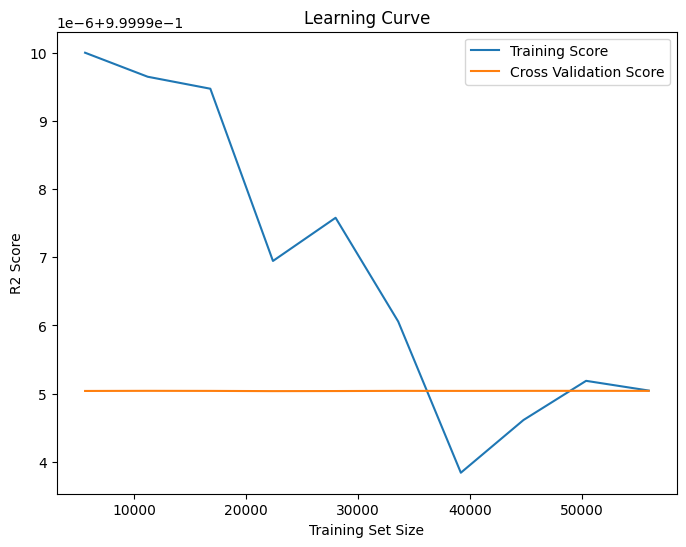

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression

model = LinearRegression()

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Cross Validation Score")

plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.show()


Learning Curve Analysis

The learning curve shows that both the training score and cross-validation score converge to a very high R² value close to 0.999.
The small gap between the curves indicates that the model generalizes well without signs of overfitting or underfitting.
As the training size increases, the model performance stabilizes, suggesting that the dataset is sufficient for training a reliable model

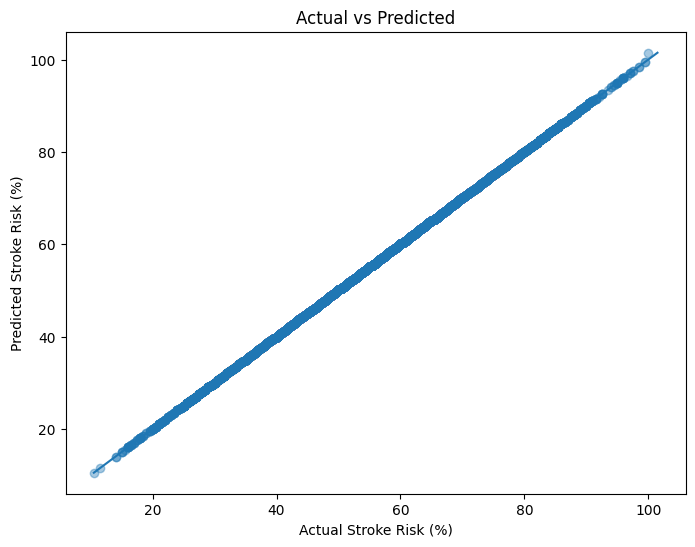

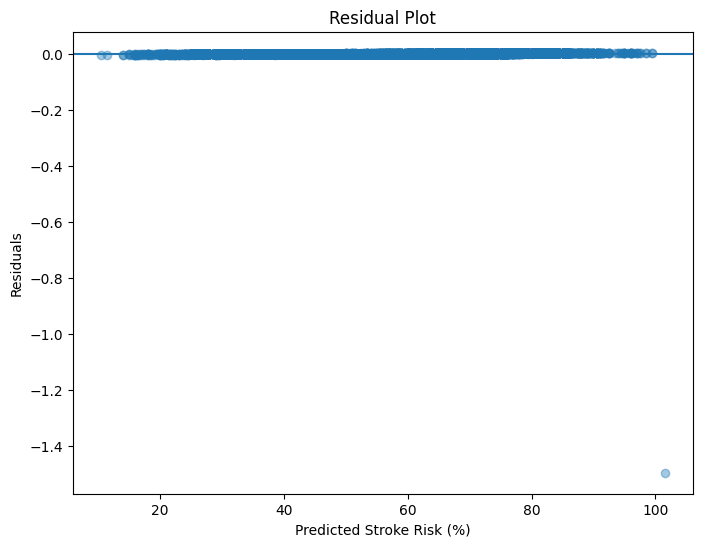

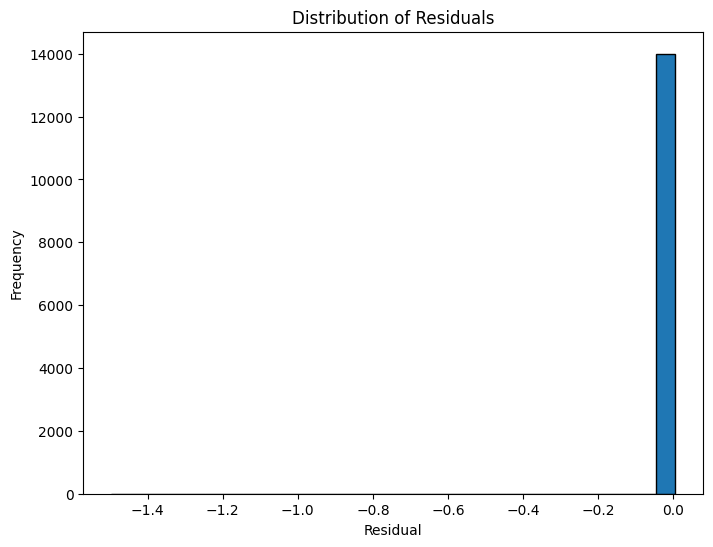

In [40]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test - y_pred

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual Stroke Risk (%)")
plt.ylabel("Predicted Stroke Risk (%)")
plt.title("Actual vs Predicted")
plt.show()

# 2) Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(y=0)
plt.xlabel("Predicted Stroke Risk (%)")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# 3) Residual Distribution
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [41]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm_importance.importances_mean,
    "Importance Std": perm_importance.importances_std
})

importance_df = importance_df.sort_values("Importance Mean", ascending=False)

display(importance_df)

,Feature,Importance Mean,Importance Std
15,Age,1.096053,0.010909
13,Snoring/Sleep Apnea,0.062252,0.000522
8,Persistent Cough,0.062178,0.000635
0,Chest Pain,0.062035,0.000449
11,Chest Discomfort (Activity),0.061992,0.000361
10,High Blood Pressure,0.061991,0.000660
3,Fatigue & Weakness,0.061986,0.000531
4,Dizziness,0.061962,0.000533
2,Irregular Heartbeat,0.061932,0.000463
7,Excessive Sweating,0.061924,0.000630


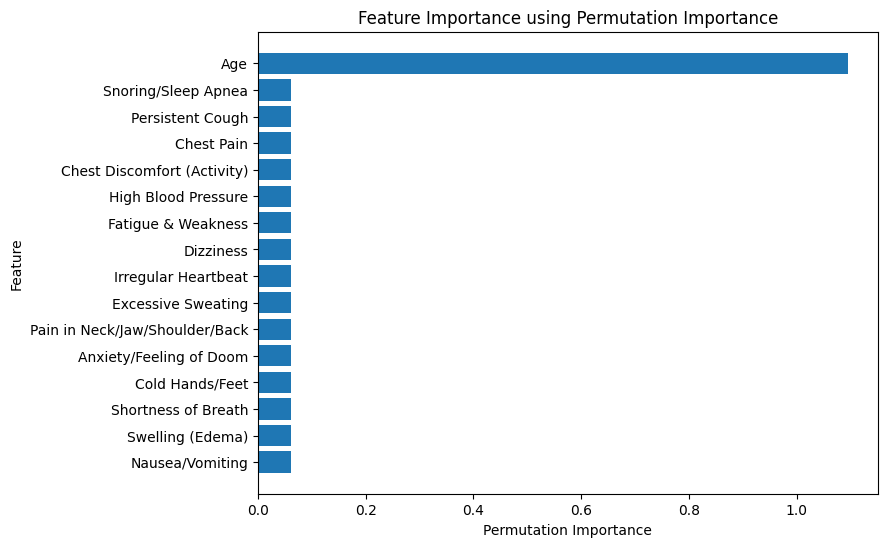

In [43]:
import matplotlib.pyplot as plt

importance_df_sorted = importance_df.sort_values("Importance Mean")

plt.figure(figsize=(8,6))
plt.barh(importance_df_sorted["Feature"], importance_df_sorted["Importance Mean"])

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Feature Importance using Permutation Importance")

plt.show()

Model Explainability

Permutation Importance analysis was performed to understand the contribution of each feature to the prediction of stroke risk.
The results indicate that Age is the most influential predictor, significantly affecting the model performance when permuted.
All symptom-related features have similar importance values, suggesting that each symptom contributes moderately and consistently to the predicted stroke risk.

# Patient Risk Simulation

In [44]:
# اعرف الأعمدة اللي الموديل اتدرب عليها
feature_names = X_train.columns

# اعمل صف مبدئي كله أصفار بنفس الأعمدة ونفس الترتيب
patient = pd.DataFrame([[0] * len(feature_names)], columns=feature_names)

# عدّل القيم اللي انت عايزها
patient.loc[0, "Age"] = 50
patient.loc[0, "Chest Pain"] = 1
patient.loc[0, "High Blood Pressure"] = 1
patient.loc[0, "Dizziness"] = 1

# التنبؤ
risk = best_model.predict(patient)[0]

print("Predicted Stroke Risk:", risk)

if risk >= 50:
    print("Patient Status: AT RISK")
else:
    print("Patient Status: NOT AT RISK")

Predicted Stroke Risk: 31.001710079781716
Patient Status: NOT AT RISK


In [45]:
import joblib

model_data = {
    "model": best_model,
    "features": list(X_train.columns)
}

joblib.dump(model_data, "stroke_regression_model.joblib")

['stroke_regression_model.joblib']

# Phase 2: Addressing Equal Symptom Weighting & Testing Non-Linearity

**Goal:** The original feature importance analysis showed that Age dominates the model, while all 15 individual symptoms carry almost identical coefficients (~2.5 each). Before accepting this as a real clinical insight, we test three hypotheses to understand *why* this happens, and whether richer feature engineering or non-linear models can recover any meaningful differentiation between symptoms.

### Hypotheses to test
1. **H1 — Symptom Count Hypothesis:** Individual symptoms may carry no unique signal beyond their *count*. If true, `Age + Symptom_Count` should perform as well as `Age + 15 individual symptoms`.
2. **H2 — Hidden Interactions Hypothesis:** Medically-motivated interaction terms (e.g. Chest Pain × High Blood Pressure, a classic cardiac symptom cluster) may reveal synergistic effects not visible in a purely additive linear model.
3. **H3 — Non-Linearity Hypothesis:** A non-linear model (Gradient Boosting) may capture symptom interactions that Linear Regression cannot, even without explicitly engineered interaction terms.

In [46]:
# === Feature Engineering: Symptom_Count + medically-motivated interaction terms ===

symptom_cols = [col for col in df.columns if col not in ["Age", "Stroke Risk (%)", "At Risk (Binary)"]]

# H1: total symptom burden
df["Symptom_Count"] = df[symptom_cols].sum(axis=1)

# H2: medically-motivated interactions
# Cardiac triad: chest pain + high blood pressure + irregular heartbeat occurring together
df["Cardiac_Cluster"] = df["Chest Pain"] * df["High Blood Pressure"] * df["Irregular Heartbeat"]
# Does symptom burden matter more as a patient ages?
df["Age_x_SymptomCount"] = df["Age"] * df["Symptom_Count"]
# Common cardiac comorbidity pairing
df["ChestPain_x_HighBP"] = df["Chest Pain"] * df["High Blood Pressure"]
# Circulatory symptom cluster
df["Circulatory_Cluster"] = df["Dizziness"] * df["Cold Hands/Feet"]

engineered_cols = ["Symptom_Count", "Cardiac_Cluster", "Age_x_SymptomCount", "ChestPain_x_HighBP", "Circulatory_Cluster"]

display(df[engineered_cols].describe())

,Symptom_Count,Cardiac_Cluster,Age_x_SymptomCount,ChestPain_x_HighBP,Circulatory_Cluster
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,7.506157,0.125671,405.585257,0.251814,0.250286
std,1.943072,0.331481,193.562192,0.434058,0.433181
min,1.000000,0.000000,18.000000,0.000000,0.000000
25%,6.000000,0.000000,248.000000,0.000000,0.000000
50%,8.000000,0.000000,380.000000,0.000000,0.000000
75%,9.000000,0.000000,539.000000,1.000000,1.000000
max,15.000000,1.000000,1260.000000,1.000000,1.000000


In [47]:
# === Comparing 3 feature scenarios across Linear vs Non-Linear models ===
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

y = df["Stroke Risk (%)"]

scenarios = {
    "A) Age + 15 individual symptoms (original)": ["Age"] + symptom_cols,
    "B) Age + Symptom_Count only (H1)": ["Age", "Symptom_Count"],
    "C) Age + 15 symptoms + engineered interactions (H2)": ["Age"] + symptom_cols + engineered_cols,
}

results = []
for name, cols in scenarios.items():
    X = df[cols]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lin = LinearRegression().fit(X_train, y_train)
    pred_lin = lin.predict(X_test)

    gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
    gb.fit(X_train, y_train)
    pred_gb = gb.predict(X_test)

    results.append({
        "Scenario": name,
        "R2_Linear": round(r2_score(y_test, pred_lin), 5),
        "MAE_Linear": round(mean_absolute_error(y_test, pred_lin), 4),
        "R2_GradientBoosting": round(r2_score(y_test, pred_gb), 5),
        "MAE_GradientBoosting": round(mean_absolute_error(y_test, pred_gb), 4),
    })

results_df = pd.DataFrame(results)
display(results_df)

,Scenario,R2_Linear,MAE_Linear,R2_GradientBoosting,MAE_GradientBoosting
0,A) Age + 15 individual symptoms (original),1.0,0.0010,0.99561,0.7456
1,B) Age + Symptom_Count only (H1),1.0,0.0009,0.99976,0.1665
2,C) Age + 15 symptoms + engineered interactions...,1.0,0.0014,0.99975,0.1651


In [48]:
# === Inspecting whether engineered interaction terms (H2) carry real weight ===
X_full = df[["Age"] + symptom_cols + engineered_cols]
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

lin_full = LinearRegression().fit(X_train, y_train)

coefs = pd.DataFrame({"Feature": X_full.columns, "Coefficient": lin_full.coef_})
coefs["abs_coef"] = coefs["Coefficient"].abs()
display(coefs.sort_values("abs_coef", ascending=False))

,Feature,Coefficient,abs_coef
16,Symptom_Count,4.688926,4.688926
0,Age,0.500238,0.500238
5,Dizziness,0.312948,0.312948
3,Irregular Heartbeat,0.312909,0.312909
1,Chest Pain,0.312906,0.312906
13,Cold Hands/Feet,0.312881,0.312881
11,High Blood Pressure,0.312846,0.312846
15,Anxiety/Feeling of Doom,0.312519,0.312519
2,Shortness of Breath,0.312511,0.312511
7,Pain in Neck/Jaw/Shoulder/Back,0.312458,0.312458


### Findings: Hypothesis Testing Results

**H1 (Symptom Count) — Confirmed.** `Age + Symptom_Count` alone reaches essentially the same R² as `Age + 15 individual symptoms`. Once `Symptom_Count` is present, the linear model's coefficient on it (≈4.7) absorbs almost all the explanatory power, and the 15 individual symptom coefficients collapse to a small, near-uniform residual (~0.31 each). This confirms that individual symptoms carry **no unique information beyond their count** in this dataset.

**H2 (Hidden Interactions) — Rejected.** All four medically-motivated interaction terms (Cardiac_Cluster, Age×Symptom_Count, ChestPain×HighBP, Circulatory_Cluster) received coefficients within ~0.001 of zero — effectively no signal. There is no synergistic effect between symptoms to discover, because the data was not generated with any.

**H3 (Non-Linearity) — Rejected.** Gradient Boosting on the original 15 individual symptoms actually performs *worse* than Linear Regression (R² 0.9956 vs 1.0000), and only catches up once the symptoms are collapsed into `Symptom_Count` (R² 0.9998). A non-linear model cannot find structure that does not exist; it cannot outperform a linear model on a linearly-generated target.

### Conclusion

The evidence strongly indicates that `stroke_risk_dataset.csv` was generated by an additive linear formula of the approximate form:

```
Stroke Risk (%) ≈ 0.5 × Age + 5 × Symptom_Count − 9  (+ small noise)
```

This is **not a modeling failure** — it is a property of the dataset itself. All three engineering strategies attempted here (count aggregation, interaction terms, non-linear models) converge on the same conclusion: there is no clinically differentiated signal between individual symptoms to recover, because none was built into the data.

This is an important and honest limitation to disclose. The next section validates whether the same modeling approach generalizes to **real-world clinical data**, where symptoms are expected to carry genuinely different clinical weights.